# STA for Hatano-Nelson Model 

This notebook uses the Krylov expansion to numerically find AGP for Hatano-Nelson model. The Hamiltonian is given by:
$$
H(t) = \sum_{n=1}^{N-1} \left[\frac{J}{2} e^{a h(t)} c_n^\dagger c_{n+1}+ \frac{J}{2} e^{-a h(t)} c_{n+1}^\dagger c_n+ U\, c_n^\dagger c_n c_{n+1}^\dagger c_{n+1}\right]
$$

In [1]:
using LinearAlgebra, SparseMatricesCSR, SparseArrays, Plots, ProgressMeter
include("Hatano_Nelson.jl")  #call the Hatano_Nelson module to build the Hamiltonian and its time derivative
using .Hatano_Nelson

include("Arnoldi.jl") #include the Arnoldi module
using .Arnoldi 

In [ ]:
#setup the parameters for the Hatano-Nelson model
N    = 4                #number of sites (Article has N=8, requires more computation time but the code works fine)
Np   = Int64(N/2)              # half filling

J, U, a, h0, τ = 1.0, 1.0, 1.0, 0.1, 1.0 #set the other necessary parameters

function H_dHdt(t, τ)
    H_matrix, dHdt_matrix = Hatano_Nelson.build_H_and_dHdt(N, J, U, a, h0, τ, t) #return the Hamiltonian and its time derivative at time t
    return H_matrix, dHdt_matrix
end

function graph(a_list)
    plot(1:length(a_list), real.(a_list)) #plot the a coefficients to check their behavior
end;

comm(a,b) = a*b-b*a
function AGP_test(H, dHdt, H_CD)
    test_mat = comm(H, im*dHdt + comm(H,H_CD))
    return maximum(abs.(test_mat))
end;

In [3]:
using Base.Threads, ProgressMeter
function AGP_array(τ,M)
    dt = τ / M
    J, U, a, h0 = 1.0, 1.0, 1.0, 0.1

    times = collect(0:dt:τ)  # time points for evolution

    AGP_list = Vector{Matrix{ComplexF64}}(undef, M)
    comm_test_list = Vector{Float64}(undef, M)

    for j in 1:M
        t = times[j]
        H,dHdt = Hatano_Nelson.build_H_and_dHdt(N, J, U, a, h0, τ, t)
        H_cd = Arnoldi.AGP_Arnoldi(H, dHdt)
        AGP_list[j] = H + H_cd
        comm_test_list[j] = AGP_test(H, dHdt, H_cd)
    end
    return AGP_list, comm_test_list
end

AGP_array (generic function with 1 method)

# Hamiltonian Simulation

In [4]:
# Initialize the state and compute the eigenvalues and eigenvectors of the initial Hamiltonian
J, U, a, h0 = 1.0, 1.0, 1.0, 0.1
H0 = Hatano_Nelson.build_H_and_dHdt(N, J, U, a, h0, τ, 0.0)[1] #get the Hamiltonian at time t=0.0

Diagonalization = eigen(Matrix(H0))
eigvals, eigvecs = Diagonalization.values, Diagonalization.vectors

ψ = eigvecs[:,1]
ψ /= norm(ψ)

function ramp_evolution(τ; M=100) # Function to evolve the state using the ramp method
    dt = τ / M
    J, U, a, h0 = 1.0, 1.0, 1.0, 0.1

    times = collect(0:dt:τ)  # time points for evolution
    ψt = copy(ψ)

    # Evolution loop
    for t in times[1:end-1]
        H = Hatano_Nelson.build_H_and_dHdt(N, J, U, a, h0, τ, t)[1]
        U_mat = exp(-im * Matrix(H) * dt)  # exact exp (small dim)
        ψt = U_mat * ψt
        ψt /= norm(ψt)  # normalize at each step
    end
    # Final energy
    H_final = Hatano_Nelson.build_H_and_dHdt(N, J, U, a, h0, τ, τ)[1]
    E_end = ψt' * H_final * ψt

    eig_final = eigen(Matrix(H_final)).vectors


    return ψt, real(E_end), imag(E_end), H_final
end

ramp_evolution (generic function with 1 method)

In [5]:
τ_list = collect(1:0.5:50) # List of τ values for ramp evolution
E_diff_list= Vector{Float64}(undef, length(τ_list)) # Initialize a vector to store energy differences
E_diff_list_imag = Vector{Float64}(undef, length(τ_list)) # Initialize a vector to store imaginary energy differences

@threads for i in eachindex(τ_list)
    τ = τ_list[i]
    ψ_final, E_real, E_imag, _ = ramp_evolution(τ) # Evolve the state using the ramp method
    E_diff_list[i] = E_real - real(eigvals[1]) # Store the difference between the final energy and the ground state energy
    E_diff_list_imag[i] = E_imag - imag(eigvals[1])
end

max_Eτ = maximum(abs.(E_diff_list + im*E_diff_list_imag)); # Find the maximum energy difference

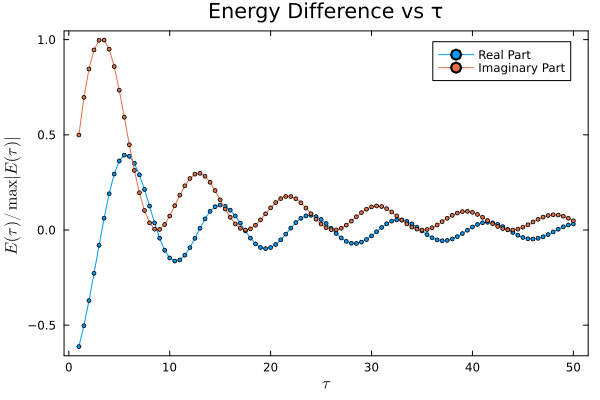

In [6]:
#Plot the results
using LaTeXStrings
plot(τ_list, E_diff_list/max_Eτ, marker=:o, markersize = 2, label = "Real Part")
plot!(τ_list, E_diff_list_imag/max_Eτ, marker=:o, markersize = 2, label = "Imaginary Part")
plot!(xlabel=L"$τ$", ylabel=L"$E(τ)/\max|E(τ)|$", title="Energy Difference vs τ", legend=:topright, grid = false, frame = :box)

# AGP Simulation

In [7]:
# Initialize the state and compute the eigenvalues and eigenvectors of the initial Hamiltonian
J, U, a, h0 = 1.0, 1.0, 1.0, 0.1
H0 = Hatano_Nelson.build_H_and_dHdt(N, J, U, a, h0, τ, 0.0)[1] #get the Hamiltonian at time t=0.0

Diagonalization = eigen(Matrix(H0))
eigvals, eigvecs = Diagonalization.values, Diagonalization.vectors

ψ = eigvecs[:,1]
ψ /= norm(ψ)

function ramp_evolution_with_AGP(τ; M=100) # Function to evolve the state using the ramp method
    dt = τ / M
    J, U, a, h0 = 1.0, 1.0, 1.0, 0.1

    times = collect(0:dt:τ)  # time points for evolution
    ψt = copy(ψ)

    AGP_list, AGP_err_list = AGP_array(τ, M)

    # Evolution loop
    for j in 1:M
        t = times[j]
        H = AGP_list[j]
        U_mat = exp(-im * Matrix(H) * dt)  # exact exp (small dim)
        ψt = U_mat * ψt
        ψt /= norm(ψt)  # normalize at each step
    end
    # Final energy
    H_final = Hatano_Nelson.build_H_and_dHdt(N, J, U, a, h0, τ, τ)[1]
    E_end = ψt' * H_final * ψt

    #eig_final = eigen(Matrix(H_final)).vectors

    return ψt, real(E_end), imag(E_end), AGP_err_list   #, H_final
end


ramp_evolution_with_AGP (generic function with 1 method)

In [8]:
τ_CD_list = collect(1:1:50) # List of τ values for ramp evolution
E_diff_CD_list= Vector{Float64}(undef, length(τ_CD_list)) # Initialize a vector to store energy differences
E_diff_list_CD_imag = Vector{Float64}(undef, length(τ_CD_list)) # Initialize a vector to store imaginary energy differences

p = Progress(length(τ_CD_list))
@threads for i in eachindex(τ_CD_list)
    τ = τ_CD_list[i]
    ψ_final, E_real, E_imag = ramp_evolution_with_AGP(τ) # Evolve the state using the ramp method
    E_diff_CD_list[i] = E_real - real(eigvals[1]) # Store the difference between the final energy and the ground state energy
    E_diff_list_CD_imag[i] = E_imag - imag(eigvals[1])
    next!(p)
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:10


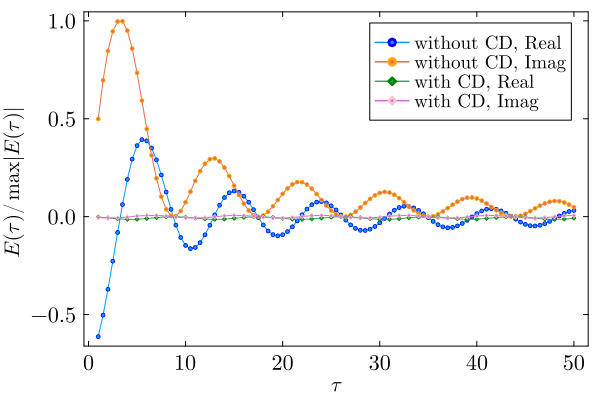

In [9]:
#Plot the results
using LaTeXStrings
p = plot(titlefontsize=18, guidefontsize=16, tickfontsize=14, legendfontsize=12, labelfontsize = 14)
plot!(τ_list, E_diff_list/max_Eτ, marker=:o, markersize = 2, markerstrokecolor = :blue, label = "without CD, Real", frame=:box,grid=false)
plot!(τ_list, E_diff_list_imag/max_Eτ, marker=:o, markersize = 2,markerstrokecolor = :orange, label = "without CD, Imag", fontfamily="Computer Modern")
plot!(τ_CD_list, E_diff_CD_list/max_Eτ, marker=:diamond, markersize = 2,markerstrokecolor = :green, label = "with CD, Real")
plot!(τ_CD_list, E_diff_list_CD_imag/max_Eτ, marker=:diamond, markersize = 2,markerstrokecolor = :pink, label = "with CD, Imag")
plot!(xlabel=L"$τ$", ylabel=L"$E(τ)/\max|E(τ)|$", legend=:topright)
#savefig(p,"Excess_energy.pdf")